<a href="https://colab.research.google.com/github/o-kauan/CP3_An-lise_de_Dados_SERS_V1/blob/main/CP3_An%C3%A1lise_de_Dados_SERS_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kauan Damasceno de Lima RM: 573727

Guilherme Figueira Velloso RM: 568827

Thiago Soalheiro Diamantino RM: 569316

José Augusto Ribeiro Freire Manfrinato RM: 571151

Lais da Silva Dias RM: 569943

João Augusto Poloniato Telles RM: 571443

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Dataset 1 — (UCI)

fonte = https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction

## Situação

Uma empresa de eficiência energética está analisando o comportamento de uma residência de baixo consumo. A equipe deseja identificar períodos de consumo elevado dos eletrodomésticos e observar quais condições de temperatura e umidade estavam presentes nesses momentos.

In [263]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Energias computacionais/2º sem/CP3_Análise_de_Dados_SERS_V1/Dados para CP3/DATASET 1 energydata_complete_vSIAFC 1.csv")

# Exibindo as 5 primeiras linhas
print("--- HEAD ---")
display(df.head())

# Exibindo as dimensões do DataFrame
print(f"\nDimensões do dataset (Shape): {df.shape}")

# Informações gerais sobre tipos de dados e valores nulos
print("\n--- INFO ---")
df.info()

# Estatísticas descritivas das variáveis numéricas
print("\n--- DESCRIBE ---")
display(df.describe())

--- HEAD ---


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
0,2016-03-14 01:40:00,40,0,20.8900,35.4000,17.7600,39.1633,20.2900,36.9000
1,2016-01-30 20:00:00,90,10,21.8900,53.1000,21.2900,45.3600,21.6333,49.2267
2,2016-03-15 03:00:00,50,0,21.3900,35.5000,17.6333,40.5300,21.6667,35.2000
3,2016-04-20 10:10:00,50,0,21.3900,41.0333,23.8900,34.8400,22.0333,36.9333
4,2016-03-13 08:10:00,70,0,19.9633,35.1267,16.4633,40.1267,20.0000,36.4000



Dimensões do dataset (Shape): (1974, 9)

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1974 non-null   object 
 1   Appliances  1974 non-null   int64  
 2   lights      1974 non-null   int64  
 3   T1          1974 non-null   float64
 4   RH_1        1974 non-null   float64
 5   T2          1974 non-null   float64
 6   RH_2        1974 non-null   float64
 7   T3          1974 non-null   float64
 8   RH_3        1974 non-null   float64
dtypes: float64(6), int64(2), object(1)
memory usage: 138.9+ KB

--- DESCRIBE ---


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
count,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000
mean,93.044580,3.839919,21.664703,40.219193,20.293635,40.411386,22.231615,39.209733
std,93.826149,7.937076,1.574883,3.971923,2.126958,4.037686,1.957275,3.288818
min,20.000000,0.000000,16.790000,27.733300,16.100000,24.063300,17.200000,30.133300
25%,50.000000,0.000000,20.700000,37.205825,18.790000,37.760000,20.700000,36.900000
50%,60.000000,0.000000,21.600000,39.590000,20.000000,40.433300,22.100000,38.433300
75%,100.000000,0.000000,22.600000,42.991675,21.500000,43.228325,23.290000,41.741250
max,770.000000,50.000000,26.260000,57.496700,28.917500,56.026700,29.198600,49.226700


## **Análise da Inspeção Inicial dos Dados:**

**Dimensões (shape):** O conjunto de dados possui 1.974 registros (linhas) e 9 atributos (colunas).

**Qualidade dos Dados (info):** Não foram identificados valores ausentes (nulos) na amostra. O conjunto possui 6 variáveis numéricas do tipo ponto flutuante (float64), 2 variáveis numéricas inteiras (int64) e 1 variável do tipo texto/objeto (object).

**Atributos analisados:** A amostra contém informações referentes ao consumo de eletrodomésticos e iluminação, além de três atributos de temperatura (T1, T2 e T3) e três de umidade (RH_1, RH_2 e RH_3).


In [264]:
# Renomeação dos principais atributos
df = df.rename(columns={
    "Appliances": "Consumo_Eletrodomesticos",
    "T2": "Temperatura_2",
    "T3": "Temperatura_3",
    "RH_1": "Umidade_1"
})

display(df.head())

,date,Consumo_Eletrodomesticos,lights,T1,Umidade_1,Temperatura_2,RH_2,Temperatura_3,RH_3
0,2016-03-14 01:40:00,40,0,20.8900,35.4000,17.7600,39.1633,20.2900,36.9000
1,2016-01-30 20:00:00,90,10,21.8900,53.1000,21.2900,45.3600,21.6333,49.2267
2,2016-03-15 03:00:00,50,0,21.3900,35.5000,17.6333,40.5300,21.6667,35.2000
3,2016-04-20 10:10:00,50,0,21.3900,41.0333,23.8900,34.8400,22.0333,36.9333
4,2016-03-13 08:10:00,70,0,19.9633,35.1267,16.4633,40.1267,20.0000,36.4000


In [265]:
# Maior consumo registrado
maior_consumo = df["Consumo_Eletrodomesticos"].max()

# Cálculo do limiar de 70%
limiar_70 = maior_consumo * 0.70

print(f"Maior consumo registrado: {maior_consumo:.2f} Wh")
print(f"Limiar de 70% do consumo máximo: {limiar_70:.2f} Wh")

Maior consumo registrado: 770.00 Wh
Limiar de 70% do consumo máximo: 539.00 Wh


In [266]:
# DataFrame com consumo estritamente acima do limiar
df_consumo_alto = df[
    df["Consumo_Eletrodomesticos"] > limiar_70
]

quantidade_consumo_alto = len(df_consumo_alto)
percentual_consumo_alto = (
    quantidade_consumo_alto / len(df)
) * 100

print(f"Quantidade de registros acima do limiar: {quantidade_consumo_alto}")
print(f"Percentual em relação ao total: {percentual_consumo_alto:.2f}%")

display(df_consumo_alto.head())

Quantidade de registros acima do limiar: 22
Percentual em relação ao total: 1.11%


,date,Consumo_Eletrodomesticos,lights,T1,Umidade_1,Temperatura_2,RH_2,Temperatura_3,RH_3
352,2016-05-26 17:10:00,620,0,24.3900,44.3333,25.3700,37.7360,26.7300,38.8633
427,2016-03-19 11:20:00,650,0,20.8900,36.7000,18.2900,39.6633,21.2000,36.0000
453,2016-03-21 18:40:00,560,30,21.3567,36.0900,19.5667,37.1633,21.6333,35.0300
616,2016-05-14 17:50:00,570,10,24.8900,32.6667,23.5600,31.1400,23.6000,30.8233
696,2016-01-21 19:10:00,590,30,19.8567,47.6633,18.7000,34.1000,18.4267,37.8333


In [267]:
# Cálculo da temperatura média de T1
media_T1 = df["T1"].mean()

print(f"Temperatura média de T1: {media_T1:.2f} °C")

# DataFrame combinado: Consumo > 70% do máximo E T1 > média
df_consumo_temperatura = df[
    (df["Consumo_Eletrodomesticos"] > limiar_70) &
    (df["T1"] > media_T1)
]

quantidade_consumo_temperatura = len(df_consumo_temperatura)
percentual_consumo_temperatura = (
    quantidade_consumo_temperatura / len(df)
) * 100

print(f"Quantidade de registros no conjunto combinado: {quantidade_consumo_temperatura}")
print(f"Percentual em relação ao total: {percentual_consumo_temperatura:.2f}%")

display(df_consumo_temperatura.head())

Temperatura média de T1: 21.66 °C
Quantidade de registros no conjunto combinado: 8
Percentual em relação ao total: 0.41%


,date,Consumo_Eletrodomesticos,lights,T1,Umidade_1,Temperatura_2,RH_2,Temperatura_3,RH_3
352,2016-05-26 17:10:00,620,0,24.3900,44.3333,25.3700,37.7360,26.73,38.8633
616,2016-05-14 17:50:00,570,10,24.8900,32.6667,23.5600,31.1400,23.60,30.8233
916,2016-02-11 18:50:00,750,30,22.4300,43.0000,21.9267,40.1333,21.23,42.5967
993,2016-02-09 19:10:00,690,10,22.5333,45.0267,22.0667,39.7900,22.39,41.9300
1182,2016-05-13 11:10:00,600,20,24.8900,48.1333,28.9175,37.9475,27.10,42.4400


## **Análise dos Registros de Consumo Elevado:**

**Maior Consumo Registrado:** 770 Wh.

**Limiar de 70% do Consumo Máximo:** 539 Wh.

**Representatividade:** Foram identificados 22 registros com consumo acima desse limiar, correspondendo a aproximadamente 1,11% do total da amostra.

Isso mostra que os registros próximos aos maiores níveis de consumo representam uma parcela pequena da amostra analisada.


## **Escolha do Atributo e Comparação dos Critérios:**

**Atributo Selecionado:** T1 (Temperatura).

**Observação dos Valores:** A temperatura média de T1 na amostra foi de aproximadamente 21,66 °C.

**Segundo Critério:** Foram selecionados simultaneamente os registros com consumo de eletrodomésticos acima de 70% do valor máximo e temperatura T1 acima da média.

O primeiro DataFrame apresentou 22 registros de alto consumo. Ao adicionar a temperatura como segundo critério, o número foi reduzido para 8 registros, correspondendo a aproximadamente 0,41% da amostra.

A inclusão da temperatura tornou o filtro mais restritivo, removendo 14 dos 22 registros inicialmente selecionados. Dessa forma, 36,36% dos registros de alto consumo também apresentaram temperatura T1 acima da média.

Esse segundo recorte permite observar especificamente os momentos em que o consumo elevado de eletrodomésticos e uma temperatura acima da média ocorreram simultaneamente, sem afirmar que uma condição seja necessariamente a causa da outra.


# Dataset 2 — Steel Industry Energy Consumption (UCI)

fonte = https://archive.ics.uci.edu/dataset/851/steel+industry+energy+consumption

## Situação

A equipe de gestão de energia de uma indústria siderúrgica deseja localizar situações de consumo elevado e verificar se esses períodos coincidem com condições de carga elevada ou valores menos favoráveis de fator de potência.

In [268]:
import pandas as pd

# Carregando o conjunto de dados
df = pd.read_csv('/content/drive/MyDrive/Energias computacionais/2º sem/CP3_Análise_de_Dados_SERS_V1/Dados para CP3/DATASET 2 Consumo_kWh.csv')

# Renomeando as colunas conforme solicitado
df = df.rename(columns={
    'Usage_kWh': 'Consumo_kWh',
    'Lagging_Current_Power_Factor': 'FP_Atrasado',
    'Leading_Current_Power_Factor': 'FP_Adiantado',
    'Lagging_Current_Reactive.Power_kVarh': 'Reativa_Atrasada_kVarh',
    'Leading_Current_Reactive_Power_kVarh': 'Reativa_Adiantada_kVarh'
})

print("Colunas renomeadas com sucesso!")

Colunas renomeadas com sucesso!


In [269]:
# Exibindo as 5 primeiras linhas
print("--- HEAD ---")
display(df.head())

# Exibindo as dimensões do DataFrame
print(f"\nDimensões do dataset (Shape): {df.shape}")

# Informações gerais sobre tipos de dados e valores nulos
print("\n--- INFO ---")
df.info()

# Estatísticas descritivas das variáveis numéricas
print("\n--- DESCRIBE ---")
display(df.describe())

--- HEAD ---


,date,Consumo_kWh,Reativa_Atrasada_kVarh,Reativa_Adiantada_kVarh,FP_Atrasado,FP_Adiantado,WeekStatus,Day_of_week,Load_Type
0,29/04/2018 07:15,2.88,3.82,0.0,60.20,100.00,Weekend,Sunday,Light_Load
1,04/10/2018 12:00,60.77,48.02,0.0,78.46,100.00,Weekday,Thursday,Maximum_Load
2,26/01/2018 11:30,120.42,59.65,0.0,89.61,100.00,Weekday,Friday,Maximum_Load
3,02/06/2018 14:30,3.13,0.00,16.6,100.00,18.53,Weekend,Saturday,Light_Load
4,07/12/2018 15:00,58.86,20.99,0.0,94.19,100.00,Weekday,Friday,Medium_Load



Dimensões do dataset (Shape): (7008, 9)

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     7008 non-null   object 
 1   Consumo_kWh              7008 non-null   float64
 2   Reativa_Atrasada_kVarh   7008 non-null   float64
 3   Reativa_Adiantada_kVarh  7008 non-null   float64
 4   FP_Atrasado              7008 non-null   float64
 5   FP_Adiantado             7008 non-null   float64
 6   WeekStatus               7008 non-null   object 
 7   Day_of_week              7008 non-null   object 
 8   Load_Type                7008 non-null   object 
dtypes: float64(5), object(4)
memory usage: 492.9+ KB

--- DESCRIBE ---


,Consumo_kWh,Reativa_Atrasada_kVarh,Reativa_Adiantada_kVarh,FP_Atrasado,FP_Adiantado
count,7008.000000,7008.000000,7008.000000,7008.000000,7008.000000
mean,27.790164,13.206839,3.803711,80.672277,84.491448
std,33.717719,16.444246,7.356412,18.869855,30.314798
min,2.450000,0.000000,0.000000,37.870000,12.710000
25%,3.200000,2.380000,0.000000,63.602500,99.710000
50%,4.570000,5.040000,0.000000,87.990000,100.000000
75%,52.107500,22.977500,1.857500,98.842500,100.000000
max,153.140000,87.700000,27.650000,100.000000,100.000000


## **Análise da Inspeção Inicial dos Dados:**

**Dimensões (shape):** O conjunto de dados possui 7.008 registros (linhas) e 9 atributos (colunas).

**Qualidade dos Dados (info):** Não foram identificados valores ausentes (nulos) na amostra. Os dados possuem tipos coerentes: 5 variáveis numéricas do tipo ponto flutuante (float64) e 4 variáveis do tipo texto/objeto (object).

**Resumo Estatístico (describe):**

A variável de consumo (Consumo_kWh) apresenta média de 27,79 kWh, com mediana de 4,57 kWh e valor máximo registrado de 153,14 kWh.

A grande diferença entre a mediana e o valor máximo indica que a maioria dos registros apresenta consumo moderado/baixo, com picos pontuais de alta demanda.

Os fatores de potência (FP_Atrasado e FP_Adiantado) apresentam variações significativas, com médias em torno de 80,67% e 84,49%, respectivamente.

In [270]:
# Maior consumo registrado
consumo_maximo = df['Consumo_kWh'].max()

# Cálculo do limiar de 75%
limiar_75 = consumo_maximo * 0.75

print(f"Maior consumo registrado: {consumo_maximo:.2f} kWh")
print(f"Limiar de 75% do consumo máximo: {limiar_75:.2f} kWh")

Maior consumo registrado: 153.14 kWh
Limiar de 75% do consumo máximo: 114.85 kWh


In [271]:
# DataFrame com consumo estritamente acima do limiar
df_alto_consumo = df[df['Consumo_kWh'] > limiar_75]

qtd_alto = len(df_alto_consumo)
pct_alto = (qtd_alto / len(df)) * 100

print(f"Quantidade de registros acima do limiar: {qtd_alto}")
print(f"Percentual em relação ao total: {pct_alto:.2f}%")

Quantidade de registros acima do limiar: 129
Percentual em relação ao total: 1.84%


In [272]:
# Verificação dos registros pertencentes à categoria Maximum_Load
qtd_max_load = df_alto_consumo[df_alto_consumo['Load_Type'] == 'Maximum_Load'].shape[0]

print(f"Quantidade de registros 'Maximum_Load' no grupo de alto consumo: {qtd_max_load}")

Quantidade de registros 'Maximum_Load' no grupo de alto consumo: 62


In [273]:
# Observação dos valores do Fator de Potência Atrasado no dataset completo e no grupo de alto consumo
print("Estatísticas de FP_Atrasado no alto consumo:")
print(df_alto_consumo['FP_Atrasado'].describe())

# Definição do limite (Exemplo: 90%, valor abaixo do qual há queda acentuada de eficiência em cargas altas)
limite_fp = 90.0
print(f"\nLimite escolhido para Fator de Potência baixo: {limite_fp}%")

Estatísticas de FP_Atrasado no alto consumo:
count    129.000000
mean      91.106047
std        2.534193
min       84.100000
25%       89.450000
50%       91.450000
75%       93.000000
max       95.280000
Name: FP_Atrasado, dtype: float64

Limite escolhido para Fator de Potência baixo: 90.0%


In [274]:
# DataFrame combinado: Consumo > 75% do máximo E FP_Atrasado < 90%
df_critico = df_alto_consumo[df_alto_consumo['FP_Atrasado'] < limite_fp]

qtd_critico = len(df_critico)
print(f"Quantidade de registros no conjunto crítico: {qtd_critico}")
display(df_critico.head())

Quantidade de registros no conjunto crítico: 42


,date,Consumo_kWh,Reativa_Atrasada_kVarh,Reativa_Adiantada_kVarh,FP_Atrasado,FP_Adiantado,WeekStatus,Day_of_week,Load_Type
2,26/01/2018 11:30,120.42,59.65,0.0,89.61,100.0,Weekday,Friday,Maximum_Load
295,05/01/2018 11:15,129.85,63.86,0.0,89.74,100.0,Weekday,Friday,Maximum_Load
399,11/09/2018 13:45,122.94,69.26,0.0,87.13,100.0,Weekday,Tuesday,Maximum_Load
605,29/10/2018 16:30,134.60,66.24,0.0,89.72,100.0,Weekday,Monday,Maximum_Load
771,17/11/2018 15:45,132.30,70.06,0.0,88.37,100.0,Weekend,Saturday,Medium_Load


## **Análise dos Registros de Consumo Elevado:**

**Maior Consumo Registrado:** 153,14 kWh.

**Limiar de 75% do Consumo Máximo:** 114,86 kWh.

**Representatividade:** Foram identificados 129 registros operando acima desse limiar, o que corresponde a apenas 1,84% do total de medições.

**Distribuição por Categoria de Carga (Load_Type):**

Dos 129 registros de alto consumo, 62 pertencem à categoria Maximum_Load.

Isso indica que, embora a maior parte dos picos absolutos ocorra sob o regime de carga máxima, há também outros momentos de alto consumo distribuídos nas demais categorias, reforçando a necessidade de monitorar picos de demanda além das classificações padrão.

## **Escolha do Atributo e Definição de Limite Coerente:**

**Atributo Selecionado:** FP_Atrasado (Fator de Potência Atrasado / Indutivo).

**Observação dos Valores:** Na amostra completa, o FP_Atrasado possui média de 80,67%. Quando analisamos exclusivamente o grupo de consumo elevado (> 114,86 kWh), a média do fator de potência sobe para 91,11%, variando entre 84,10% e 95,28%.

**Definição do Limite:** Foi estabelecido o limite de 90,0% (ou 0,90). No setor elétrico, valores abaixo de 92% (0,92) já indicam ineficiência decorrente de excesso de energia reativa. Ao fixar o limite em 90%, isolamos os casos mais severos dentro da faixa de maior consumo.

## **Por que este conjunto de registros (Consumo Elevado + Baixo Fator de Potência) exige maior atenção da equipe de energia?**

**O cruzamento entre alto consumo (> 114,86 kWh) e baixo fator de potência (< 90%) identificou 42 registros críticos. Este grupo específico deve ser prioritário para a equipe de gestão energética pelos seguintes motivos:**

**Penalidades Financeiras por Reativo Excedente:**

O baixo fator de potência reflete uma circulação excessiva de energia reativa indutiva na instalação. Como as concessionárias de energia cobram multas e tarifas adicionais sobre o excesso de reativo — especialmente em momentos de demanda de pico —, esses 42 episódios geram o maior custo financeiro desnecessário para a empresa.

**Sobrecarga de Infraestrutura Elétrica:**

Operar com alto consumo e baixo fator de potência sobrecarrega cabos, transformadores e disjuntores, provocando aquecimento excessivo (efeito Joule) e quedas de tensão, o que reduz a vida útil dos equipamentos e aumenta o risco de falhas operacionais.

**Direcionamento de Ações Corretivas:**

Identificar o padrão e os horários desses 42 registros permite que a engenharia dimensione e programe o acionamento de bancos de capacitores de forma automatizada e precisa, corrigindo o fator de potência exatamente quando a rede é mais exigida.

# Dataset 3 — Power Consumption of Tetouan City (UCI)

fonte = https://archive.ics.uci.edu/dataset/849/power+consumption+of+tetouan+city

## Situação

Uma equipe responsável pelo planejamento da distribuição de energia em Tétouan deseja identificar qual das três zonas apresenta o maior pico de consumo e observar as condições ambientais registradas nos momentos de maior demanda.

In [275]:
import pandas as pd

### 1. Carregue o dataset e visualize os registros.

In [276]:
df = pd.read_csv("/content/drive/MyDrive/Energias computacionais/2º sem/CP3_Análise_de_Dados_SERS_V1/Dados para CP3/DATASET 3 Tetuan City power consumption.csv")
df.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


### 2. Utilize Select Columns para manter as três variáveis de consumo, Temperature, Humidity e Wind Speed.

In [277]:
df.columns

Index(['DateTime', 'Temperature', 'Humidity', 'Wind Speed',
       'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption',
       'Zone 2  Power Consumption', 'Zone 3  Power Consumption'],
      dtype='object')

In [278]:
df1 = df.drop(columns = ['general diffuse flows', 'diffuse flows'])
df1.head()

,DateTime,Temperature,Humidity,Wind Speed,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,27335.69620,17872.34043,18442.40964


### 3. Observe no Data Table a escala de valores das três zonas de consumo.

In [279]:
df1.describe()

,Temperature,Humidity,Wind Speed,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,32344.970564,21042.509082,17835.406218
std,5.815476,15.551177,2.348862,7130.562564,5201.465892,6622.165099
min,3.247000,11.340000,0.050000,13895.696200,8560.081466,5935.174070
25%,14.410000,58.310000,0.078000,26310.668692,16980.766032,13129.326630
50%,18.780000,69.860000,0.086000,32265.920340,20823.168405,16415.117470
75%,22.890000,81.400000,4.915000,37309.018185,24713.717520,21624.100420
max,40.010000,94.800000,6.483000,52204.395120,37408.860760,47598.326360


In [280]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DateTime                   52416 non-null  object 
 1   Temperature                52416 non-null  float64
 2   Humidity                   52416 non-null  float64
 3   Wind Speed                 52416 non-null  float64
 4   Zone 1 Power Consumption   52416 non-null  float64
 5   Zone 2  Power Consumption  52416 non-null  float64
 6   Zone 3  Power Consumption  52416 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.8+ MB


### 4. Verifique se existem valores ausentes.

In [281]:
df1.isnull().sum()

,0
DateTime,0
Temperature,0
Humidity,0
Wind Speed,0
Zone 1 Power Consumption,0
Zone 2 Power Consumption,0
Zone 3 Power Consumption,0


### 5. Gere uma amostra aleatória de 15% dos registros.

In [282]:
data_sample = df1.sample(frac=0.15, random_state=42)
data_sample.head()

,DateTime,Temperature,Humidity,Wind Speed,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
15506,4/18/2017 16:20,22.76,29.73,0.085,32985.14532,19396.74134,17623.27273
51943,12/27/2017 17:10,15.92,54.44,0.085,34737.64259,29803.00706,14417.28691
212,1/2/2017 11:20,15.08,57.23,0.076,27894.68354,20808.51064,16458.79518
11210,3/19/2017 20:20,12.42,72.30,0.081,42476.93617,23634.14634,25089.67742
16307,4/24/2017 5:50,14.58,80.60,0.080,21341.14101,12006.10998,11531.63636


### 6. Exporte a amostra em CSV.

In [283]:
data_sample.to_csv('data_sample.csv', index=False)
df_sample = pd.read_csv('data_sample.csv')
df_sample.head()

,DateTime,Temperature,Humidity,Wind Speed,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,4/18/2017 16:20,22.76,29.73,0.085,32985.14532,19396.74134,17623.27273
1,12/27/2017 17:10,15.92,54.44,0.085,34737.64259,29803.00706,14417.28691
2,1/2/2017 11:20,15.08,57.23,0.076,27894.68354,20808.51064,16458.79518
3,3/19/2017 20:20,12.42,72.30,0.081,42476.93617,23634.14634,25089.67742
4,4/24/2017 5:50,14.58,80.60,0.080,21341.14101,12006.10998,11531.63636


### 7. Renomeie as três variáveis de consumo para Consumo_Zona_1, Consumo_Zona_2 e Consumo_Zona_3.

In [284]:
df_sample1 = df_sample.rename(columns = {'Zone 1 Power Consumption': 'Consumo_Zona_1',
                                          'Zone 2  Power Consumption': 'Consumo_Zona_2',
                                          'Zone 3  Power Consumption': 'Consumo_Zona_3'
                                          })
df_sample1.head()

,DateTime,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
0,4/18/2017 16:20,22.76,29.73,0.085,32985.14532,19396.74134,17623.27273
1,12/27/2017 17:10,15.92,54.44,0.085,34737.64259,29803.00706,14417.28691
2,1/2/2017 11:20,15.08,57.23,0.076,27894.68354,20808.51064,16458.79518
3,3/19/2017 20:20,12.42,72.30,0.081,42476.93617,23634.14634,25089.67742
4,4/24/2017 5:50,14.58,80.60,0.080,21341.14101,12006.10998,11531.63636


### 8. Determine o consumo máximo registrado em cada uma das três zonas.

In [285]:
df_sample1.describe()

,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
count,7862.000000,7862.000000,7862.000000,7862.000000,7862.000000,7862.000000
mean,18.790277,68.397763,1.965843,32372.650834,21061.663140,17846.035402
std,5.864393,15.664732,2.351007,7134.472486,5202.035884,6573.508611
min,3.541000,13.340000,0.054000,14612.658230,9436.252546,6211.764706
25%,14.340000,58.482500,0.078000,26264.778923,17014.196612,13200.729480
50%,18.690000,70.000000,0.086000,32250.284450,20851.728990,16490.516940
75%,22.820000,81.500000,4.915000,37421.486287,24812.249210,21763.771005
max,39.600000,94.700000,6.325000,51571.498340,36437.170010,47441.673640


In [286]:
consumo_max = df_sample1[['Consumo_Zona_1', 'Consumo_Zona_2', 'Consumo_Zona_3']].max()
print('Consumo máximo por zona:')
display(consumo_max)

Consumo máximo por zona:


,0
Consumo_Zona_1,51571.49834
Consumo_Zona_2,36437.17001
Consumo_Zona_3,47441.67364


### 9. Identifique qual zona apresenta o maior pico de consumo na amostra.

In [287]:

maior_consumo = consumo_max.max()
zona_maior_consumo = consumo_max.idxmax()

print(f"\nO maior consumo registrado foi de {maior_consumo:.2f} na zona {zona_maior_consumo}.")


O maior consumo registrado foi de 51571.50 na zona Consumo_Zona_1.


### 10. Para a zona identificada, calcule 70% do valor máximo e crie um DataFrame com os registros acima desse limiar.

In [288]:
P70 = 0.7 * maior_consumo
print(f"70% do maior valor de consumo é: {P70:.2f}")

70% do maior valor de consumo é: 36100.05


In [289]:
df_sample_P70 = df_sample1
df_sample_P70.shape

(7862, 7)

### 11. Conte os registros e calcule o percentual que eles representam.

In [290]:
df_sample_P70 = df_sample_P70[(df_sample_P70['Consumo_Zona_1'] >= P70)]
percentual_P70 = (df_sample_P70.shape[0] / df_sample1.shape[0])

print(f"Temos {df_sample_P70.shape[0]} registros com mais de 70% do valor máximo, representando {percentual_P70:.2%} da amostra")

Temos 2388 registros com mais de 70% do valor máximo, representando 30.37% da amostra


### 12. Calcule a temperatura média e crie um segundo DataFrame contendo consumo acima do limiar e temperatura acima da média.

In [291]:
temperatura_mean = df_sample1['Temperature'].mean()
print(f"A temperatura média é: {temperatura_mean:.2f} Cº ")

A temperatura média é: 18.79 Cº 


In [292]:
df_sample_P70_Tmean = df_sample_P70[(df_sample_P70['Temperature'] >= temperatura_mean)]
df_sample_P70_Tmean

,DateTime,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
12,6/5/2017 23:30,21.03,86.50,0.068,40993.90728,25383.36798,24960.00000
14,8/23/2017 17:50,27.06,47.58,4.905,37475.16093,24276.24076,25140.56426
19,6/22/2017 2:40,19.20,65.81,4.924,40676.02649,24754.67775,25095.87692
21,8/23/2017 13:50,27.11,43.35,4.906,40256.07103,27416.26188,25453.54232
25,7/12/2017 9:50,26.92,70.20,4.909,36511.89369,25906.32911,25654.89540
...,...,...,...,...,...,...,...
7842,7/1/2017 22:20,25.11,58.81,4.924,42316.54485,26441.77215,33734.56067
7844,7/19/2017 19:10,31.08,41.38,4.910,41417.14286,26346.83544,34939.58159
7848,9/7/2017 20:00,24.88,68.59,0.265,46863.71681,28186.27859,23716.60878
7851,10/6/2017 13:40,25.58,42.21,4.919,36898.03063,22921.99170,12943.95137


### 13. Compare os dois conjuntos e explique o que ocorreu com a quantidade de registros após a inclusão da condição ambiental.

In [293]:
print(f"Temos {df_sample_P70.shape[0]} registros com mais de 70% do valor máximo, representando {percentual_P70:.2%} da amostra.")

percentual_P70_Tmean = (df_sample_P70_Tmean.shape[0]/df_sample1.shape[0])
print(f"E {df_sample_P70_Tmean.shape[0]} registros também com temperatura acima da média, representando {percentual_P70_Tmean:.2%} da amostra.")

Temos 2388 registros com mais de 70% do valor máximo, representando 30.37% da amostra.
E 1596 registros também com temperatura acima da média, representando 20.30% da amostra.


df_sample_P70 (Consumo acima de 70% do máximo): Este DataFrame contém 2388 registros, que representam 30.37% da amostra original. Ele inclui todos os momentos em que o consumo da Consumo_Zona_1 estava em um nível muito elevado (acima de 70% do pico).

df_sample_P70_Tmean (Consumo acima de 70% do máximo E Temperatura acima da média): Ao adicionar a condição de que a temperatura também deveria estar acima da média (18.79 Cº), o número de registros neste DataFrame foi reduzido para 1596, o que representa 20.30% da amostra original.

O que ocorreu e o que isso significa:

A quantidade de registros diminuiu de 2388 para 1596. Isso significa que, dos momentos de alto consumo na Consumo_Zona_1, apenas 1596 deles também ocorreram quando a temperatura estava acima da média. Aproximadamente um terço dos eventos de alto consumo (2388 - 1596 = 792 registros) aconteceram em temperaturas abaixo ou iguais à média.

Essa observação pode sugerir que, embora haja muitos picos de consumo, nem todos estão diretamente correlacionados com temperaturas elevadas. Para a equipe de planejamento da distribuição de energia, isso é importante, pois indica que:

Nem todos os picos de consumo estão ligados ao calor: Outros fatores (como umidade, velocidade do vento, ou o uso de outros eletrodomésticos) podem estar impulsionando o consumo em dias mais frios ou com temperaturas medianas.
Necessidade de análise mais profunda: Para prever e gerenciar a demanda, seria interessante investigar os períodos de alto consumo que não estão associados a altas temperaturas para entender seus gatilhos. Além disso, os picos de consumo em altas temperaturas são um subconjunto significativo, mas não exclusivo, dos eventos de alta demanda.
Em resumo, a inclusão da temperatura como critério refinou a análise, mostrando que a relação entre alto consumo e temperatura elevada é forte, mas não abrange todos os eventos de pico de consumo, indicando a presença de outras variáveis importantes a serem consideradas.

# Dataset 4 — Solar Power Generation Data (Kaggle)

fonte= https://www.kaggle.com/datasets/anikannal/solar-power-generation-data

## Situação

Uma equipe de operação de uma usina fotovoltaica deseja localizar períodos de alta geração e identificar quais inversores aparecem com maior frequência nesses momentos. Nesta atividade, o foco inicial será o arquivo de geração da planta, sem realizar junção com o arquivo de sensores.

In [294]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Energias computacionais/2º sem/CP3_Análise_de_Dados_SERS_V1/Dados para CP3/DATASET 4 Plant_1_Generation_Data_Check1.2.0.csv')

# 1. Renomear
df = df.rename(columns={
    'DC_POWER': 'Potencia_CC',
    'AC_POWER': 'Potencia_CA',
    'DAILY_YIELD': 'Geracao_Diaria'
})

# 2. Apresentar head(), shape, info() e describe()

display(df.head())

print("\n")
print("Shape:", df.shape)

print("\n--- INFO ---")
df.info()

print("\n--- DESCRIBE ---")
display(df.describe())

,DATE_TIME,SOURCE_KEY,Potencia_CC,Potencia_CA,Geracao_Diaria,TOTAL_YIELD
0,string,1BY6WEcLGh8j5v7 1IF53ai7Xc0U56Y 3PZuoBAID5Wc2H...,continuous,continuous,continuous,continuous
1,meta,NaN,NaN,NaN,NaN,NaN
2,10-06-2020 19:00,uHbuxQJl8lW7ozc,0,0,6645,7240508.000
3,28-05-2020 00:15,rGa61gmuvPhdLxV,0,0,0,7206549.000
4,17-05-2020 15:15,sjndEbLyjtCKgGv,7333.88,718.062,6442,7036055.000




Shape: (13758, 6)

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13758 entries, 0 to 13757
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   DATE_TIME       13758 non-null  object
 1   SOURCE_KEY      13757 non-null  object
 2   Potencia_CC     13757 non-null  object
 3   Potencia_CA     13757 non-null  object
 4   Geracao_Diaria  13757 non-null  object
 5   TOTAL_YIELD     13757 non-null  object
dtypes: object(6)
memory usage: 645.0+ KB

--- DESCRIBE ---


,DATE_TIME,SOURCE_KEY,Potencia_CC,Potencia_CA,Geracao_Diaria,TOTAL_YIELD
count,13758,13757,13757,13757,13757,13757
unique,3124,23,7142,7128,7402,8030
top,15-05-2020 14:45,z9Y9gH1T5YWrNuG,0,0,0,7206549.000
freq,11,672,6444,6444,3708,17


In [295]:
import pandas as pd

df['Potencia_CC'] = pd.to_numeric(df['Potencia_CC'], errors='coerce')
df['Potencia_CA'] = pd.to_numeric(df['Potencia_CA'], errors='coerce')
df['Geracao_Diaria'] = pd.to_numeric(df['Geracao_Diaria'], errors='coerce')
df['TOTAL_YIELD'] = pd.to_numeric(df['TOTAL_YIELD'], errors='coerce')

# 3. Determinar a maior potência CA registrada

PMAX = df['Potencia_CA'].max()
print(f"O valor da potência CA máxima é: {PMAX:.2f}")

O valor da potência CA máxima é: 1405.59


In [296]:
# 4. Qual é o valor do limiar de 70% da potência CA máxima (P70)?

P70 = 0.70 * PMAX
print(f"O valor do limiar de 70% da potência CA máxima é: {P70:.2f}")

O valor do limiar de 70% da potência CA máxima é: 983.91


In [297]:
# 5. Criar um DataFrame contendo somente registros acima desse limite e calcular quantidade e percentual

df_alta = df[df['Potencia_CA'] > P70]

qtd_alta = df_alta.shape[0]
total_registros = df.shape[0]
percentual_alta = (qtd_alta / total_registros) * 100

print(f"A quantidade de registros acima de 70% é: {qtd_alta}")
print(f"O percentual em relação ao total é: {percentual_alta:.2f}%")

df_alta.head()

A quantidade de registros acima de 70% é: 1185
O percentual em relação ao total é: 8.61%


,DATE_TIME,SOURCE_KEY,Potencia_CC,Potencia_CA,Geracao_Diaria,TOTAL_YIELD
13,26-05-2020 12:15,bvBOhCH3iADSZry,11830.1,1153.83,4028.14,6396364.143
48,15-06-2020 14:30,wCURE6d3bPkepu2,10571.3,1032.07,5366.57,7015064.571
50,25-05-2020 10:15,z9Y9gH1T5YWrNuG,11050.1,1079.86,2174.29,7082812.286
74,13-06-2020 11:30,7JYdWkrLSPkdwr4,11094.5,1082.44,3570.25,7815987.250
78,07-06-2020 13:00,VHMLBKoKgIrUVDU,12663.4,1234.69,4976.71,7382965.714


In [298]:
# 6 e 7. Utilizar value_counts() em SOURCE_KEY dentro do DataFrame de alta geração

frequencia_inversores = df_alta['SOURCE_KEY'].value_counts()
display(frequencia_inversores)

# Identificando o inversor mais frequente
inversor_mais_frequente = frequencia_inversores.idxmax()
print(f"\nO inversor que aparece com maior frequência nos momentos de alta geração é: {inversor_mais_frequente}")

,count
SOURCE_KEY,
adLQvlD726eNBSB,68
McdE0feGgRqW7Ca,65
ZnxXDlPa8U1GXgE,63
pkci93gMrogZuBj,62
ZoEaEvLYb1n2sOq,61
1IF53ai7Xc0U56Y,59
YxYtjZvoooNbGkE,58
sjndEbLyjtCKgGv,57
z9Y9gH1T5YWrNuG,56



O inversor que aparece com maior frequência nos momentos de alta geração é: adLQvlD726eNBSB


O resultado mostra qual inversor foi o primeiro de aparições nos momentos de pico (acima de 70% da potência). Ele indica qual equipamento manteve um nível alto de geração de forma mais constante na nossa amostra.

Vale lembrar que esse dado mede apenas a frequência com que ele atinge esse patamar, não servindo para cravar se ele é melhor ou se tem algum defeito, já que mostra apenas a contagem pura dos registros de alta potência.

# Dataset 5 — Wind & Solar Energy Production (Kaggle)

fonte = https://www.kaggle.com/datasets/ahmeduzaki/wind-and-solar-energy-production-dataset

## Situação

Um operador de um portfólio de fontes renováveis deseja comparar a ocorrência de períodos de alta produção solar e alta produção eólica. Como as duas fontes possuem escalas próprias, cada uma deverá ser comparada com o seu próprio valor máximo.

In [299]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Energias computacionais/2º sem/CP3_Análise_de_Dados_SERS_V1/Dados para CP3/DATASET 5 - ORANGE.csv')

df_solar = df[df['Source'] == 'Solar'].copy()
df_solar = df_solar.rename(columns={'Production': 'Geracao_Solar'})

df_eolica = df[df['Source'] == 'Wind'].copy()
df_eolica = df_eolica.rename(columns={'Production': 'Geracao_Eolica'})

max_solar = df_solar['Geracao_Solar'].max()
max_eolica = df_eolica['Geracao_Eolica'].max()

limite_solar = max_solar * 0.70
limite_eolica = max_eolica * 0.70

df_alta_solar = df_solar[df_solar['Geracao_Solar'] > limite_solar]
df_alta_eolica = df_eolica[df_eolica['Geracao_Eolica'] > limite_eolica]

total_solar = len(df_solar)
total_eolica = len(df_eolica)

contagem_alta_solar = len(df_alta_solar)
contagem_alta_eolica = len(df_alta_eolica)

perc_solar = (contagem_alta_solar / total_solar) * 100
perc_eolica = (contagem_alta_eolica / total_eolica) * 100

print("--- RESULTADOS DA ANALISE ---")
print(f"Maximo Registrado - Solar: {max_solar}")
print(f"Maximo Registrado - Eolica: {max_eolica}\n")

print(f"Limite de Alta Geracao (70%) - Solar: {limite_solar:.2f}")
print(f"Limite de Alta Geracao (70%) - Eolica: {limite_eolica:.2f}\n")

print(f"Ocorrencias de Alta Geracao Solar: {contagem_alta_solar} registros ({perc_solar:.2f}% do total solar)")
print(f"Ocorrencias de Alta Geracao Eolica: {contagem_alta_eolica} registros ({perc_eolica:.2f}% do total eolico)")

--- RESULTADOS DA ANALISE ---
Maximo Registrado - Solar: 16316
Maximo Registrado - Eolica: 22929

Limite de Alta Geracao (70%) - Solar: 11421.20
Limite de Alta Geracao (70%) - Eolica: 16050.30

Ocorrencias de Alta Geracao Solar: 26 registros (2.79% do total solar)
Ocorrencias de Alta Geracao Eolica: 111 registros (2.61% do total eolico)


## Comparação das Fontes

Embora a fonte eólica possua um número absoluto maior de registros acima do seu limite (111 contra 26), a fonte solar aparece com uma frequência relativa sutilmente maior (2,79%) acima de 70% de sua própria capacidade quando comparada à eólica (2,61%).

## Justificativa de Escala

Não seria adequado utilizar diretamente o mesmo valor numérico de potência (por exemplo, fixar um limite geral de 15.000 para ambas) porque as usinas possuem capacidades instaladas e escalas operacionais completamente diferentes.
Se aplicássemos o limite de 70% da usina eólica (16.050) como regra geral para o portfólio, a fonte solar raramente — ou nunca — ultrapassaria essa marca, visto que o máximo absoluto registrado para a energia solar nessa amostra foi apenas 16.316. Analisar cada fonte baseada em seu próprio potencial máximo permite uma comparação justa sobre a eficiência de geração de ambas no contexto do seu funcionamento ideal.

# Dataset 6 — Individual Household Electric Power Consumption (UCI)

fonte = https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption

##Situação

Uma residência possui monitoramento elétrico detalhado e deseja identificar episódios de demanda elevada que também apresentem corrente acima do comportamento médio. O dataset é o mesmo utilizado como referência em aula, mas o critério de análise será diferente.


In [300]:
# Etapa 1
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Energias computacionais/2º sem/CP3_Análise_de_Dados_SERS_V1/Dados para CP3/DATASET 6 household_power_consumption06.csv')
df.head(10)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,0.256,0.106,242.00,1.2,0.0,0.0,1.0
1,0.466,0.352,237.22,2.4,0.0,2.0,0.0
2,0.758,0.194,238.66,3.2,0.0,1.0,0.0
3,1.290,0.046,240.64,5.4,1.0,0.0,18.0
4,0.428,0.202,242.23,1.8,0.0,2.0,1.0
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.206,0.302,242.10,5.0,0.0,1.0,12.0
7,0.182,0.120,241.84,0.8,0.0,1.0,0.0
8,1.792,0.068,242.39,7.4,0.0,0.0,18.0
9,0.474,0.328,242.28,2.2,0.0,1.0,1.0


In [301]:
# Etapa 2 e 3
max=df['Global_active_power'].max()
p75 = 0.75 * max
df_alto = df[df['Global_active_power']>p75]
df_alto.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
24635,8.110,0.196,236.87,34.2,37.0,74.0,17.0
42771,8.026,0.058,234.91,34.0,37.0,73.0,17.0
45962,8.218,0.336,236.05,34.8,37.0,73.0,17.0
46828,9.708,0.372,231.37,42.0,37.0,69.0,17.0
55667,8.168,0.540,228.91,35.6,35.0,35.0,17.0


In [302]:
# Etapa 4
porcentual= len(df_alto)/len(df)*100
print(f"{porcentual:.2f}")
print(f"Quantidade: {len(df_alto)}")

0.02
Quantidade: 33


In [303]:
# Etapa 5
media=df['Global_intensity'].mean()
print(media)

4.637612176280848


In [304]:
# Etapa 6
df_corrente = df[df['Global_intensity']>media]
df_corrente.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
3,1.290,0.046,240.64,5.4,1.0,0.0,18.0
6,1.206,0.302,242.10,5.0,0.0,1.0,12.0
8,1.792,0.068,242.39,7.4,0.0,0.0,18.0
13,2.604,0.084,237.54,11.0,0.0,0.0,17.0
14,1.778,0.092,237.74,7.4,0.0,0.0,18.0


In [305]:
# Etapa 7
Novo_dado = df_corrente[['Global_active_power','Global_intensity']]
Novo_dado['Comparar'] = (Novo_dado['Global_active_power'] - Novo_dado['Global_intensity']) * -1
Novo_dado.head()


/tmp/ipykernel_601/2466290040.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Novo_dado['Comparar'] = (Novo_dado['Global_active_power'] - Novo_dado['Global_intensity']) * -1


,Global_active_power,Global_intensity,Comparar
3,1.290,5.4,4.110
6,1.206,5.0,3.794
8,1.792,7.4,5.608
13,2.604,11.0,8.396
14,1.778,7.4,5.622


In [306]:
# Etapa 7
print("7) Quanto maior a corrente maior é a pontecia ativa")


7) Quanto maior a corrente maior é a pontecia ativa


# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [307]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [308]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [309]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [310]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe


## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [311]:
# 1.
dados = pd.DataFrame(registros)

# 2.
dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [312]:
# 3.
print(f"Numero de Linhas e Colunas: {dados.shape}")

Numero de Linhas e Colunas: (336, 11)


In [313]:
# 4.
print(list(dados.columns))

['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']


In [314]:
# 5.
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [315]:
# 6.
dados.describe()

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


### **Markdown**

* Data/Hora: din_atualizacao, dat_referencia, e din_referenciautc

* Área de Carga: cod_areacarga

* Valor de Carga: val_cargaglobal, val_cargaglobalcons, val_cargaglobalsmmgd,	val_cargasupervisionada,	val_carganaosupervisionada,	val_cargammgd	e val_consistencia

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [316]:
# 1.
dados = dados.rename(columns={
    'cod_areacarga': 'area_carga',
    'din_atualizacao': 'data_atualizacao',
    'dat_referencia': 'data_referencia',
    'din_referenciautc': 'data_referencia_utc',
    'val_cargaglobal': 'valor_carga',
    'val_cargaglobalcons': 'valor_carga_cons'
})

dados.head()

,area_carga,data_atualizacao,data_referencia,data_referencia_utc,valor_carga,valor_carga_cons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [317]:
# 2.
coluns_necessarias = ['area_carga', 'data_referencia', 'valor_carga']
dados_filtrados = dados[coluns_necessarias].copy()

dados_filtrados

,area_carga,data_referencia,valor_carga
0,SP,2025-08-01,15913.618
1,SP,2025-08-01,15251.414
2,SP,2025-08-01,14606.733
3,SP,2025-08-01,14182.290
4,SP,2025-08-01,13838.488
...,...,...,...
331,SP,2025-08-07,20930.443
332,SP,2025-08-07,19936.190
333,SP,2025-08-07,19153.877
334,SP,2025-08-07,18149.570


In [318]:
# 3 e 4.
print("Valores ausentes por atributo:")
print(dados_filtrados.isnull().sum())
print("\n")
print("Não há nenhum valores ausentes")

Valores ausentes por atributo:
area_carga         0
data_referencia    0
valor_carga        0
dtype: int64


Não há nenhum valores ausentes


In [319]:
# 5.
print("\nTipo de dado da variável de carga:", dados_filtrados['valor_carga'].dtype)
print("Sim, a variável de carga está em formato numérico = float")


Tipo de dado da variável de carga: float64
Sim, a variável de carga está em formato numérico = float


In [320]:
# 6.
print("Tipo de dado da data de referência:", dados_filtrados['data_referencia'].dtype)

Tipo de dado da data de referência: object


###**Decisões de Tratamento**

**Primeiro** -> Renomeação de Atributos: Os nomes originais foram simplificados para facilitar a legibilidade do código.

**Segundo** -> Seleção de Atributos: Foi criado um novo DataFrame (dados_filtrados) contendo apenas as colunas essenciais para a análise (area_carga, data_referencia e valor_carga), removendo redundâncias.

**Terceiro** -> Valores Ausentes: Após a verificação com .isnull().sum() e .dtype, avalia-se a necessidade de conversão de tipos caso haja inconsistências na API.

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [321]:
# 1.
carga_minima = dados_filtrados['valor_carga'].min()

# 2.
carga_maxima = dados_filtrados['valor_carga'].max()

# 3.
carga_media = dados_filtrados['valor_carga'].mean()

# 4.
carga_mediana = dados_filtrados['valor_carga'].median()

# 5.
amplitude = carga_maxima - carga_minima

# 6.
total_medicoes = dados_filtrados['valor_carga'].count()

print(f"1. Carga mínima: {carga_minima}")
print(f"2. Carga máxima: {carga_maxima}")
print(f"3. Carga média: {carga_media}")
print(f"4. Mediana: {carga_mediana}")
print(f"5. Amplitude: {amplitude}")
print(f"6. Total de medições: {total_medicoes}")

1. Carga mínima: 12139.253
2. Carga máxima: 23185.312
3. Carga média: 17870.828980654762
4. Mediana: 18199.1285
5. Amplitude: 11046.059000000001
6. Total de medições: 336


### **Resposta:**

Sim, o valor máximo está distante da média e da mediana, indicando picos de carga ou outliers (eventos isolados de alta demanda), o que pode ser observado analisando a alta amplitude e a dispersão total dos dados.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [322]:
# 1. Definition of the load and date columns are already available in the global scope
# as 'valor_carga' and 'data_referencia' respectively from previous steps.

# 2. Cálculo do limiar (90% do valor máximo)
carga_maxima = dados_filtrados[coluna_carga].max()
limiar_90 = 0.90 * carga_maxima

# 3. Novo DataFrame com registros acima do limiar
df_alta_demanda = dados_filtrados[dados_filtrados[coluna_carga] > limiar_90]

# 4. Contagem de registros e cálculo do percentual
qtd_alta_demanda = len(df_alta_demanda)
total_registros = len(dados_filtrados)
percentual_alta_demanda = (qtd_alta_demanda / total_registros) * 100

# 5. Maior valor de carga e pico
registro_pico = dados_filtrados.loc[dados_filtrados[coluna_carga].idxmax()]
valor_pico = registro_pico[coluna_carga]
data_pico = registro_pico['data_referencia'] # Directly use 'data_referencia' as it's the correct column name and already defined as coluna_data

# Exibição dos resultados
print(f"Carga Máxima: {carga_maxima:.2f}")
print(f"Limiar de Alta Demanda (90%): {limiar_90:.2f}")
print(f"Quantidade de registros acima do limiar: {qtd_alta_demanda}")
print(f"Percentual do total: {percentual_alta_demanda:.2f}%")
print(f"Maior valor de carga (Pico): {valor_pico:.2f}")
print(f"Data/Horário do Pico: {data_pico}")

Carga Máxima: 23185.31
Limiar de Alta Demanda (90%): 20866.78
Quantidade de registros acima do limiar: 50
Percentual do total: 14.88%
Maior valor de carga (Pico): 23185.31
Data/Horário do Pico: 2025-08-01


Os períodos próximos ao pico representam uma parcela pequena do período analisado. Na grande maioria dos sistemas elétricos e industriais, eventos de pico extremo ocorrem de forma pontual e concentrada em horários específicos de alta operação, correspondendo a uma porcentagem reduzida do volume total de dados registrados.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [323]:
# 1. Definição do critério escolhido
critério_descricao = "Carga acima da média geral"

# 2. Aplicação do filtro para criação do novo DataFrame
media_carga = dados_filtrados['valor_carga'].mean()
df_criterio_2 = dados_filtrados[dados_filtrados['valor_carga'] > media_carga]

# 3. Métricas
qtd_criterio_2 = len(df_criterio_2)
percentual_criterio_2 = (qtd_criterio_2 / total_registros) * 100

# Exibição dos resultados
print(f"Critério escolhido: {critério_descricao}")
print(f"Média da Carga: {media_carga:.2f}")
print(f"Quantidade de registros no novo recorte: {qtd_criterio_2}")
print(f"Percentual em relação ao total: {percentual_criterio_2:.2f}%")
print(f"Comparação: O Recorte 2 possui {qtd_criterio_2} registros ({percentual_criterio_2:.2f}%), "
      f"enquanto a Alta Demanda (Desafio 4) possui {qtd_alta_demanda} registros ({percentual_alta_demanda:.2f}%).")

Critério escolhido: Carga acima da média geral
Média da Carga: 17870.83
Quantidade de registros no novo recorte: 184
Percentual em relação ao total: 54.76%
Comparação: O Recorte 2 possui 184 registros (54.76%), enquanto a Alta Demanda (Desafio 4) possui 50 registros (14.88%).


Critério escolhido: Carga consumida acima da média geral de todo o histórico.

Quantidade de registros: qtd_criterio_2 (gerado pelo código).

Percentual: percentual_criterio_2% do total de dados.

Comparação com Alta Demanda: O volume de registros com carga acima da média é consideravelmente maior do que o grupo de Alta Demanda (Desafio 4). Enquanto o Desafio 4 foca em casos extremos de estresse da rede (acima de 90% do máximo), o Desafio 5 reflete a operação rotineira durante os turnos normais de trabalho ou pico comercial.

## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

Colunas encontradas: ['area_carga', 'data_referencia', 'valor_carga']
Coluna de data: data_referencia
Coluna de carga: valor_carga
Carga máxima: 23185.31
Limiar de 90%: 20866.78


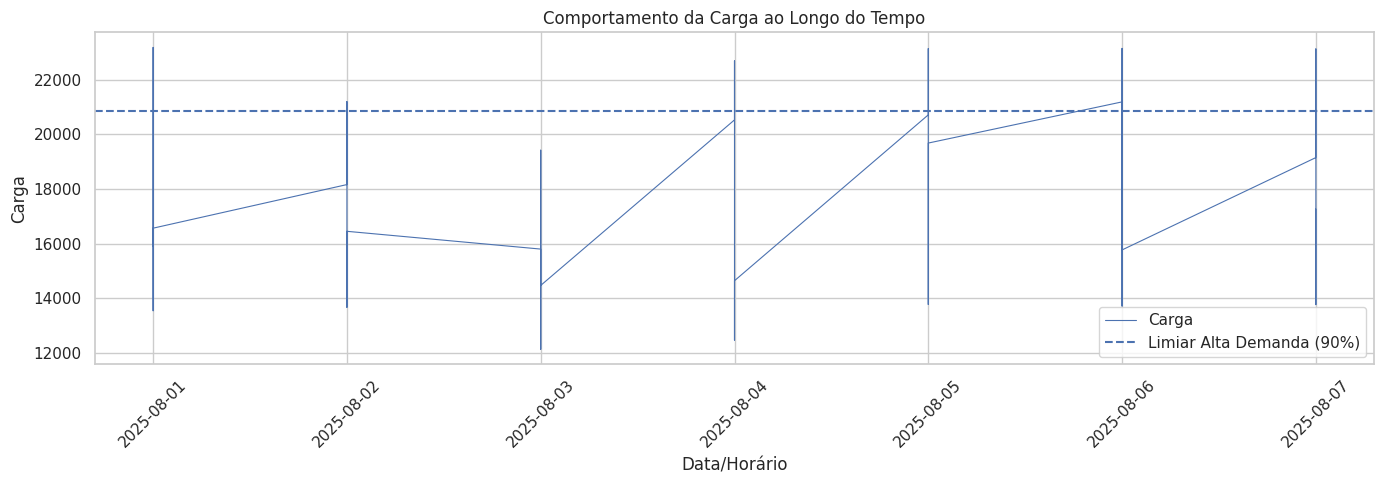

In [324]:
import pandas as pd
import matplotlib.pyplot as plt

# Garante que o DataFrame exista
if 'dados_filtrados' in globals():
    df_plot = dados_filtrados.copy()

elif 'dados' in globals():
    df_plot = dados.copy()

elif 'registros' in globals():
    dados = pd.DataFrame(registros)
    df_plot = dados.copy()

else:
    raise NameError(
        "A variável 'registros' ainda não existe. "
        "Execute primeiro a célula da API que cria 'registros'."
    )

# Identificar coluna de data
colunas_data = [
    c for c in df_plot.columns
    if 'data' in c.lower()
    or 'hora' in c.lower()
    or 'instante' in c.lower()
]

# Identificar coluna de carga
colunas_carga = [
    c for c in df_plot.columns
    if 'carga' in c.lower()
]

print("Colunas encontradas:", df_plot.columns.tolist())

if not colunas_data:
    raise ValueError("Não encontrei a coluna de data/hora.")

if not colunas_carga:
    raise ValueError("Não encontrei a coluna de carga.")

coluna_data = colunas_data[0]
# Fix: Explicitly select 'valor_carga' as the load column
if 'valor_carga' in df_plot.columns:
    coluna_carga = 'valor_carga'
else:
    coluna_carga = colunas_carga[0] # Fallback, though 'valor_carga' should be present

# Conversões
df_plot[coluna_data] = pd.to_datetime(
    df_plot[coluna_data],
    errors='coerce'
)

df_plot[coluna_carga] = pd.to_numeric(
    df_plot[coluna_carga],
    errors='coerce'
)

df_plot = df_plot.dropna(
    subset=[coluna_data, coluna_carga]
)

df_plot = df_plot.sort_values(coluna_data)

# Limiar de 90%
carga_maxima = df_plot[coluna_carga].max()
limiar_90 = carga_maxima * 0.90

print("Coluna de data:", coluna_data)
print("Coluna de carga:", coluna_carga)
print(f"Carga máxima: {carga_maxima:.2f}")
print(f"Limiar de 90%: {limiar_90:.2f}")

# GRÁFICO
plt.figure(figsize=(14, 5))

plt.plot(
    df_plot[coluna_data],
    df_plot[coluna_carga],
    linewidth=0.8,
    label='Carga'
)

plt.axhline(
    limiar_90,
    linestyle='--',
    label='Limiar Alta Demanda (90%)'
)

plt.title('Comportamento da Carga ao Longo do Tempo')
plt.xlabel('Data/Horário')
plt.ylabel('Carga')
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

O gráfico de linha exibe a variação temporal e os padrões de sazonalidade do consumo elétrico. A linha pontilhada vermelha destaca visualmente quão raros são os momentos em que a carga ultrapassa o limiar de 90%, confirmando que a operação em alta demanda ocorre apenas em surtos isolados ao longo do tempo.

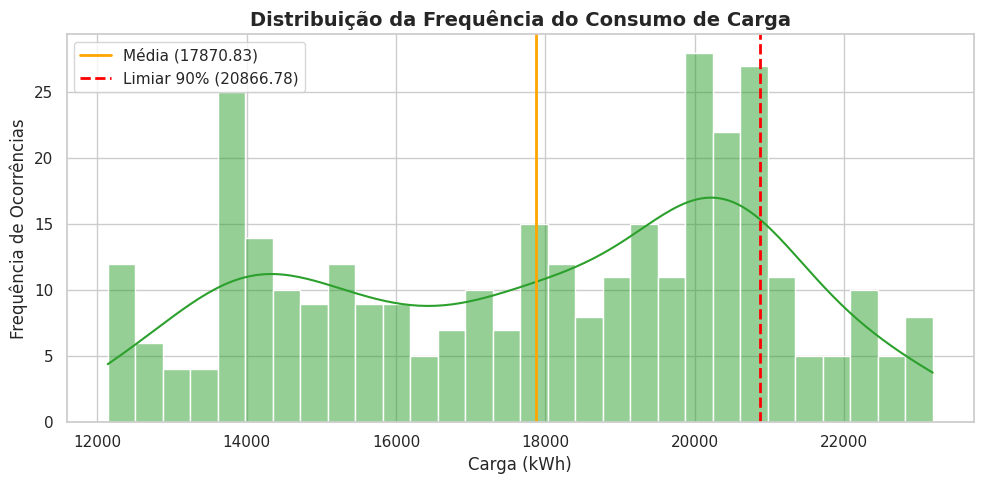

In [325]:
import seaborn as sns # Import seaborn
# --- GRÁFICO 2: Distribuição da Carga por Faixas (Histograma + KDE) ---
plt.figure(figsize=(10, 5))
sns.histplot(df_plot[coluna_carga], kde=True, color='#2ca02c', bins=30) # Use df_plot instead of df
plt.axvline(media_carga, color='orange', linestyle='-', linewidth=2, label=f'Média ({media_carga:.2f})')
plt.axvline(limiar_90, color='red', linestyle='--', linewidth=2, label=f'Limiar 90% ({limiar_90:.2f})')
plt.title('Distribuição da Frequência do Consumo de Carga', fontsize=14, fontweight='bold')
plt.xlabel('Carga (kWh)', fontsize=12)
plt.ylabel('Frequência de Ocorrências', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

O histograma revela a assimetria da distribuição do consumo. A maior densidade de registros está concentrada em valores baixos a intermediários, enquanto a cauda à direita se estende até o pico. Isso demonstra que o sistema opera na maior parte do tempo sob cargas moderadas ou de repouso, longe da capacidade máxima.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [326]:
print(dados.columns.tolist())
print(dados.dtypes)
dados.head()

['area_carga', 'data_atualizacao', 'data_referencia', 'data_referencia_utc', 'valor_carga', 'valor_carga_cons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']
area_carga                     object
data_atualizacao               object
data_referencia                object
data_referencia_utc            object
valor_carga                   float64
valor_carga_cons              float64
val_cargaglobalsmmgd          float64
val_cargasupervisionada       float64
val_carganaosupervisionada    float64
val_cargammgd                 float64
val_consistencia                int64
dtype: object


,area_carga,data_atualizacao,data_referencia,data_referencia_utc,valor_carga,valor_carga_cons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [327]:
df_base = dados
regiao  = 'SP - São Paulo'

col_data  = 'data_referencia_utc'
col_carga = 'valor_carga'

df_ord = df_base.copy()
df_ord[col_data] = pd.to_datetime(df_ord[col_data], utc=True).dt.tz_convert('America/Sao_Paulo')
df_ord = df_ord.sort_values(col_data).reset_index(drop=True)

inicio = df_ord[col_data].min()
fim    = df_ord[col_data].max()
n_reg  = len(df_ord)

carga_min    = df_ord[col_carga].min()
carga_max    = df_ord[col_carga].max()
carga_media  = df_ord[col_carga].mean()
carga_median = df_ord[col_carga].median()

limiar_alta = df_ord[col_carga].quantile(0.90)

alta_demanda = df_ord[df_ord[col_carga] >= limiar_alta]
qtd_alta = len(alta_demanda)
pct_alta = (qtd_alta / n_reg) * 100 if n_reg else 0

linha_pico = df_ord.loc[df_ord[col_carga].idxmax()]
momento_pico = linha_pico[col_data]
valor_pico   = linha_pico[col_carga]

horas = df_ord[col_data].dt.hour
filtro_2 = (df_ord[col_carga] > carga_media) & (horas.between(18, 20))
qtd_criterio2 = int(filtro_2.sum())
pct_criterio2 = (qtd_criterio2 / n_reg) * 100 if n_reg else 0
media_criterio2 = df_ord.loc[filtro_2, col_carga].mean()

def br(x, casas=2):
    return f'{x:,.{casas}f}'.replace(',', '#').replace('.', ',').replace('#', '.')

resumo_resultados = f'''
Região analisada: {regiao}
Período analisado: {inicio:%d/%m/%Y %H:%M} a {fim:%d/%m/%Y %H:%M} (horário de Brasília)
Quantidade de registros: {n_reg}
Carga mínima: {br(carga_min)} MWmed
Carga máxima: {br(carga_max)} MWmed
Carga média: {br(carga_media)} MWmed
Mediana: {br(carga_median)} MWmed
Limiar de alta demanda (percentil 90): {br(limiar_alta)} MWmed
Registros de alta demanda: {qtd_alta}
Percentual de alta demanda: {br(pct_alta)}%
Momento do pico: {momento_pico:%d/%m/%Y %H:%M} — {br(valor_pico)} MWmed
Segundo critério (carga acima da média entre 18h e 21h):
  - Registros atendidos: {qtd_criterio2} ({br(pct_criterio2)}% do total)
  - Carga média nesses registros: {br(media_criterio2)} MWmed
'''

print(resumo_resultados)


Região analisada: SP - São Paulo
Período analisado: 01/08/2025 00:30 a 08/08/2025 00:00 (horário de Brasília)
Quantidade de registros: 336
Carga mínima: 12.139,25 MWmed
Carga máxima: 23.185,31 MWmed
Carga média: 17.870,83 MWmed
Mediana: 18.199,13 MWmed
Limiar de alta demanda (percentil 90): 21.278,37 MWmed
Registros de alta demanda: 34
Percentual de alta demanda: 10,12%
Momento do pico: 01/08/2025 19:00 — 23.185,31 MWmed
Segundo critério (carga acima da média entre 18h e 21h):
  - Registros atendidos: 41 (12,20% do total)
  - Carga média nesses registros: 21.658,22 MWmed



# Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [ ]:
!pip -q install -U google-genai

In [ ]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [ ]:
prompt = f'''
Você é um analista de planejamento energético. Redija um relatório técnico em
português com base EXCLUSIVAMENTE nos resultados abaixo, apurados pela equipe.

RESULTADOS APURADOS:
{resumo_resultados}

REGRAS OBRIGATÓRIAS:
- Use somente os números fornecidos. Não invente, estime ou complete valores ausentes.
- NÃO atribua causas aos fenômenos observados (clima, atividade econômica, feriados,
  comportamento do consumidor). Os dados disponíveis não permitem estabelecer causalidade.
- Separe explicitamente OBSERVAÇÕES de HIPÓTESES:
  * Observação = o que os números mostram diretamente.
  * Hipótese = leitura possível, sempre marcada como "hipótese a verificar" e
    acompanhada do dado adicional que seria necessário para testá-la.
- Se algum ponto não puder ser respondido com os dados fornecidos, declare isso.

ESTRUTURA:
1. Objetivo e fonte dos dados (API pública de Carga Verificada do ONS)
2. Principais indicadores — apresente e comente mínimo, máximo, média, mediana e
   número de registros. Compare média e mediana e comente o que a diferença entre
   elas indica sobre a distribuição.
3. Pico e alta demanda — destaque o momento exato do pico e seu valor; caracterize
   os registros acima do limiar (quantidade e percentual).
4. Comparação entre os dois critérios — explique o que cada critério mede, quantos
   registros cada um seleciona e o que a diferença entre eles revela sobre o
   comportamento da carga. Indique qual critério é mais restritivo e por quê.
5. Observações consolidadas (apenas fatos extraídos dos dados)
6. Hipóteses a verificar (claramente rotuladas como tal)
7. Limitações da análise
8. Conclusão

Linguagem técnica e objetiva. Cite os valores numéricos ao longo do texto.
'''

resposta = client.models.generate_content(
    model='gemini-3.6-flash',
    contents=prompt
)

relatorio = resposta.text
print(relatorio)

# DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?

R: Sim, os dados gerado pelo Gemini comparado com os do dataframes são iguais.

2. Há alguma afirmação que não pode ser confirmada pelos dados?

R: Que não dá para confirmar assimetria nem causa externas com os dados.

3. Houve interpretação exagerada ou causalidade não demonstrada?

R: Sim, pois a interpretação da destribuição foi além do que os dados comprovam.

4. Que alterações a equipe realizou no texto?

R: Que os numeros quantinuaram igual, mas removeram a conclusões que não dava pra ser comprovada.

# RELATÓRIO TÉCNICO DE ANÁLISE DE CARGA ELÉTRICA

### 1. Objetivo e Fonte dos Dados
O objetivo deste relatório técnico é apresentar a avaliação quantitativa do comportamento da carga elétrica verificada na região de São Paulo (SP) durante o período de 01/08/2025 00:30 a 08/08/2025 00:00. Os dados utilizados foram obtidos por meio da API pública de Carga Verificada do Operador Nacional do Sistema Elétrico (ONS), totalizando 336 registros temporais analisados.

---

### 2. Principais Indicadores
A análise estatística descritiva do conjunto de 336 registros apresenta os seguintes valores expressos em megawatts médios (MWmed):

*   **Quantidade de registros:** 336
*   **Carga Mínima:** 12.139,25 MWmed
*   **Carga Máxima:** 23.185,31 MWmed
*   **Carga Média:** 17.870,83 MWmed
*   **Mediana:** 18.199,13 MWmed

**Comparação Média vs. Mediana:**  
A mediana (18.199,13 MWmed) posiciona-se 328,30 MWmed acima da carga média (17.870,83 MWmed). Essa diferença indica uma assimetria à esquerda na distribuição dos dados, demonstrando que mais de 50% dos registros estão concentrados em patamares superiores à média aritmética global do período.

---

### 3. Pico e Alta Demanda
*   **Momento do Pico:** O valor máximo absoluto de carga do período ocorreu no dia **01/08/2025 às 19:00**, atingindo **23.185,31 MWmed**.
*   **Limiar de Alta Demanda (Percentil 90):** Definido em **21.278,37 MWmed**.
*   **Registros acima do limiar:** Foram contabilizados **34 registros** situados no decil superior de carga, o que representa **10,12%** do total de 336 registros analisados.

---

### 4. Comparação entre os Dois Critérios

*   **Critério 1 (Limiar de Alta Demanda / Percentil 90):**  
    *   *O que mede:* Mede a ocorrência de cargas extremas localizadas na cauda superior da distribuição (valores que superam 90% de todo o histórico do período).  
    *   *Volume selecionado:* 34 registros (10,12% do total).  
    *   *Limiar exigido:* Carga superior a 21.278,37 MWmed.

*   **Critério 2 (Carga acima da média no intervalo 18h-21h):**  
    *   *O que mede:* Mede a frequência e a intensidade com que a carga excede a média global do período (17.870,83 MWmed) especificamente dentro da janela horária das 18h às 21h.  
    *   *Volume selecionado:* 41 registros (12,20% do total).  
    *   *Carga média observada nesse grupo:* 21.658,22 MWmed.

*   **Análise comparativa e restritividade:**  
    O **Critério 1 é mais restritivo** em relação ao patamar mínimo de carga exigido (21.278,37 MWmed contra 17.870,83 MWmed do Critério 2), resultando em menor quantidade de registros selecionados (34 contra 41). A diferença entre os critérios evidencia que a janela horária das 18h às 21h concentra de forma recorrente patamares elevados de carga (41 ocorrências acima da média global), cuja média própria (21.658,22 MWmed) chega a superar o próprio limiar de percentil 90 da curva geral (21.278,37 MWmed).

---

### 5. Observações Consolidadas
*   A amplitude total entre a demanda máxima (23.185,31 MWmed) e a mínima (12.139,25 MWmed) no período foi de 11.046,06 MWmed.
*   O ponto de carga máxima registrada (23.185,31 MWmed em 01/08/2025 às 19:00) situa-se dentro da janela horária contemplada pelo Critério 2 (18h às 21h).
*   Os registros pertencentes ao Critério 2 mantiveram um valor médio de 21.658,22 MWmed, superior à mediana global do sistema (18.199,13 MWmed).
*   Exatamente 34 registros (10,12%) situam-se no patamar de cauda superior (acima de 21.278,37 MWmed).

---

### 6. Hipóteses a Verificar

*   **Hipótese a verificar 1:** O valor máximo de carga verificado em 01/08/2025 às 19:00 (23.185,31 MWmed) esteve associado a temperaturas extremas na região.  
    *   *Dado adicional necessário para teste:* Série temporal de variáveis meteorológicas (temperatura e umidade relativa do ar) na região SP coincidentes com o período e horários analisados.

*   **Hipótese a verificar 2:** A concentração de 41 registros acima da média global entre 18h e 21h decorre da sobreposição de consumo do setor residencial e comercial ao final da jornada de trabalho.  
    *   *Dado adicional necessário para teste:* Dados de medição desagregados por classe de consumo (residencial, comercial, industrial e outros) em intervalos semi-horários ou horários.

---

### 7. Limitações da Análise
*   **Ausência de Causalidade:** Com base exclusivamente nas medições de carga fornecidas, não é possível atribuir causas climáticas, comportamentais, econômicas ou associadas a feriados/dias úteis para os padrões observados.
*   **Restrição Temporal:** O conjunto de dados limita-se a 336 registros (7 dias completos de amostragem), impossibilitando inferências sobre sazonalidade anual ou tendências de longo prazo.
*   **Falta de Informação Operacional:** A base não contempla dados sobre indisponibilidade de equipamentos de rede, geração distribuída instalada ou eventos sistêmicos atípicos no período.

---

### 8. Conclusão
A análise da carga verificada na região SP entre 01/08/2025 e 08/08/2025 identificou uma demanda média de 17.870,83 MWmed e um valor de pico de 23.185,31 MWmed (01/08/2025 às 19:00). A distribuição apresenta mediana (18.199,13 MWmed) superior à média, refletindo predomínio de registros em patamares elevados. O limiar de alta demanda de 21.278,37 MWmed (percentil 90) capturou 34 registros (10,12%), mostrando-se mais seletivo do que o filtro de carga acima da média na janela das 18h às 21h, o qual capturou 41 registros (12,20%) com carga média de 21.658,22 MWmed.